# Basic Analysis of Eno River Stream Data

**About the Data**\
USGS Stream Monitoring Location Eno River at Hillsborough, NC - USGS-02085000\
Daily Mean Discharge cfs 2010-2020

**AI Statement**: Codex was used to aid in plotting pretty figures and exact syntax for ML section.

In [9]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error
import polars as pl

# Set the working directory
wd = "C:/Users/Grace/Documents/Fall26/Data_Engineering/IDS706-Assignments/data/"


In [10]:
# load data
file = wd + "daily-data-mean.csv"

flow = pd.read_csv(file)
flow.head(3)

,x,y,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified
0,-79.095556,36.071111,2bf55dc212734c469cd90fe8d976fadf,USGS-02085000,60,3,2020-12-31,125.0,ft^3/s,Approved,NaN,2025-03-11 13:33:20.467623+00:00
1,-79.095556,36.071111,2bf55dc212734c469cd90fe8d976fadf,USGS-02085000,60,3,2020-12-30,109.0,ft^3/s,Approved,NaN,2025-03-11 13:33:20.467623+00:00
2,-79.095556,36.071111,2bf55dc212734c469cd90fe8d976fadf,USGS-02085000,60,3,2020-12-29,119.0,ft^3/s,Approved,NaN,2025-03-11 13:33:20.467623+00:00


In [11]:
flow.info()

# convert time from string to datetime
flow['time'] = pd.to_datetime(flow['time'])

print(flow['qualifier'].explode().unique())


<class 'pandas.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   x                       4018 non-null   float64
 1   y                       4018 non-null   float64
 2   time_series_id          4018 non-null   str    
 3   monitoring_location_id  4018 non-null   str    
 4   parameter_code          4018 non-null   int64  
 5   statistic_id            4018 non-null   int64  
 6   time                    4018 non-null   str    
 7   value                   4018 non-null   float64
 8   unit_of_measure         4018 non-null   str    
 9   approval_status         4018 non-null   str    
 10  qualifier               27 non-null     str    
 11  last_modified           4018 non-null   str    
dtypes: float64(3), int64(2), str(7)
memory usage: 774.0 KB
<ArrowStringArray>
[nan, '['ESTIMATED']']
Length: 2, dtype: str


In [12]:
# check for duplicates
flow.duplicated().sum()

np.int64(0)

In [13]:
# check for missing intervals
dates = pd.date_range(start="2010-01-01", end="2020-12-31", freq="D")
print(len(dates))
print(len(flow))

4018
4018


In [14]:
flow_df=flow[['time','value']]
flow_df.head()

,time,value
0,2020-12-31,125.0
1,2020-12-30,109.0
2,2020-12-29,119.0
3,2020-12-28,135.0
4,2020-12-27,160.0


In [15]:
# Start Date
start_date = flow['time'].min()
print('start date:',start_date)

#End Date
end_date = flow['time'].max()
print('end date:',end_date)

# Duration
duration = end_date - start_date
print('duration:',duration)

# maximum flow
max_flow = flow['value'].max()
print('maximum flow:',max_flow)

#minimum flow
min_flow = flow['value'].min()
print('minimum flow:',min_flow)

#mean flow
mean_flow = flow['value'].mean()
print('mean flow:',mean_flow)

# Monthly Averages
flow_df['month'] = flow_df['time'].dt.month
monthly_averages = flow_df.groupby('month')['value'].mean()
print('monthly averages:',monthly_averages)

# Seasonal Averages
flow_df['season'] = flow_df['time'].dt.month.map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                                  3: 'Spring', 4: 'Spring', 5: 'Spring',
                                                  6: 'Summer', 7: 'Summer', 8: 'Summer',
                                                  9: 'Fall', 10: 'Fall', 11: 'Fall'})
seasonal_averages = flow_df.groupby('season')['value'].mean()
print('seasonal averages:',seasonal_averages)



start date: 2010-01-01 00:00:00
end date: 2020-12-31 00:00:00
duration: 4017 days 00:00:00
maximum flow: 3270.0
minimum flow: 0.22
mean flow: 59.75117969138875
monthly averages: month
1      76.709238
2     104.472058
3      82.041056
4      97.607545
5      63.959589
6      46.272455
7      22.398798
8      17.409736
9      27.801000
10     34.981202
11     56.080636
12     90.852551
Name: value, dtype: float64
seasonal averages: season
Fall      39.569960
Spring    81.024417
Summer    28.502589
Winter    90.261208
Name: value, dtype: float64


In [16]:
#yearly averages
yearly_stats = flow_df.groupby(flow_df['time'].dt.year)['value'].agg(['mean', 'max','min'])
print('yearly averages:',yearly_stats)

yearly averages:             mean     max   min
time                          
2010   38.213726  1490.0  2.12
2011   16.394822   173.0  0.22
2012   18.761393   479.0  1.29
2013   50.433397   588.0  0.70
2014   57.292164  1150.0  2.08
2015   69.851808  1650.0  1.12
2016   58.600820  1630.0  2.11
2017   53.744630  3270.0  2.77
2018   91.472110  2160.0  1.97
2019  100.042493  2760.0  1.80
2020  102.454071  1350.0  5.58


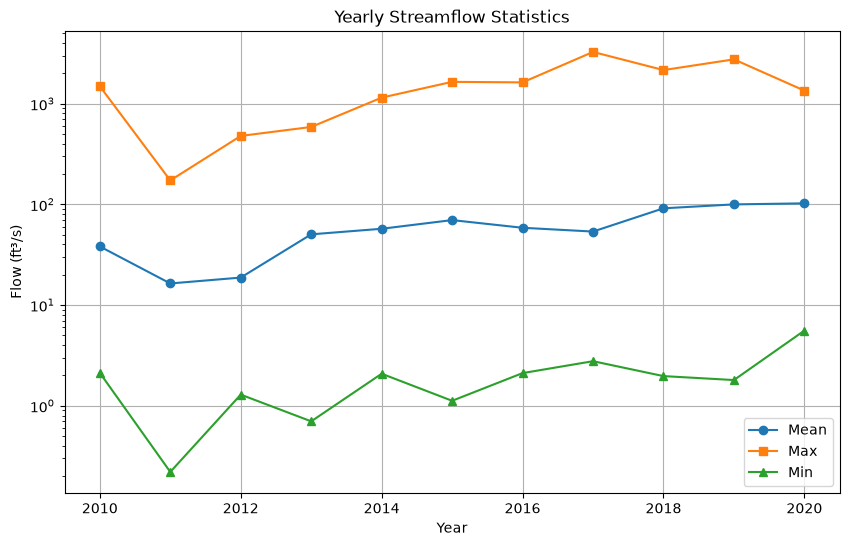

In [17]:
#  plot yearly_stats log scale
plt.figure(figsize=(10, 6))
plt.plot(yearly_stats.index, yearly_stats['mean'], marker='o', label='Mean')
plt.plot(yearly_stats.index, yearly_stats['max'], marker='s', label='Max')
plt.plot(yearly_stats.index, yearly_stats['min'], marker='^', label='Min')
plt.xlabel('Year')
plt.ylabel('Flow (ft³/s)')
plt.title('Yearly Streamflow Statistics')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()


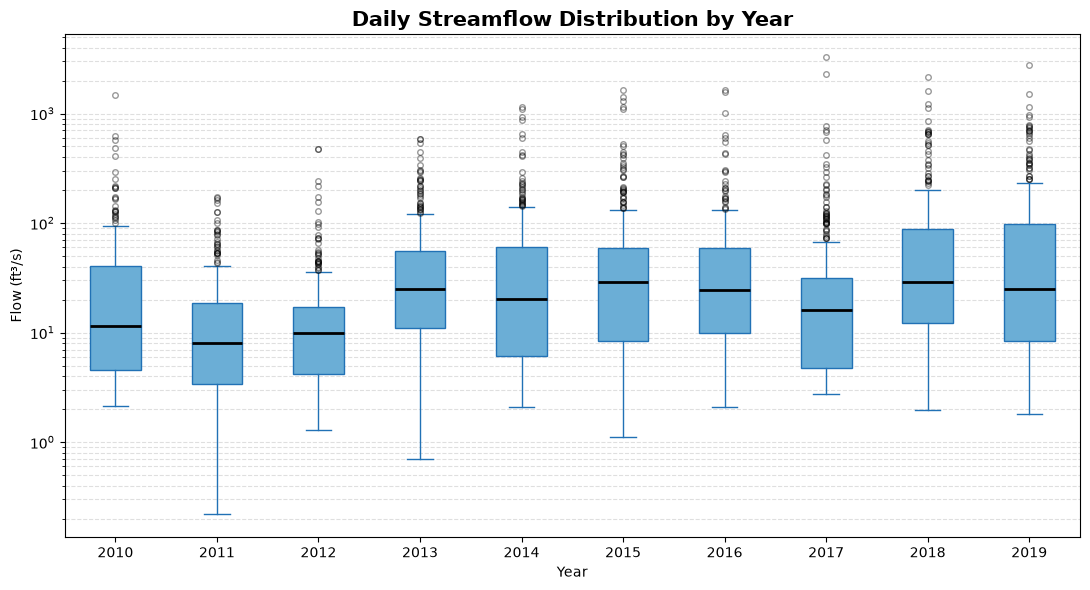

In [18]:
# yearly boxplot
# yearly flow distributions as a boxplot
year = range(2010,2020)
yearly_data = [
    flow_df.loc[flow_df["time"].dt.year == year, "value"]
    for year in year
]
# Yearly flow distributions
fig, ax = plt.subplots(figsize=(11, 6))

ax.boxplot(
    yearly_data,
    tick_labels=list(year),
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
    boxprops={"facecolor": "#6baed6", "edgecolor": "#2171b5"},
    whiskerprops={"color": "#2171b5"},
    capprops={"color": "#2171b5"},
    flierprops={"marker": "o", "markersize": 4, "alpha": 0.4},
)

ax.set_yscale("log")
ax.set_title("Daily Streamflow Distribution by Year", fontsize=15, weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Flow (ft³/s)")
ax.grid(axis="y", linestyle="--", alpha=0.4, which="both")
plt.tight_layout()
plt.show()



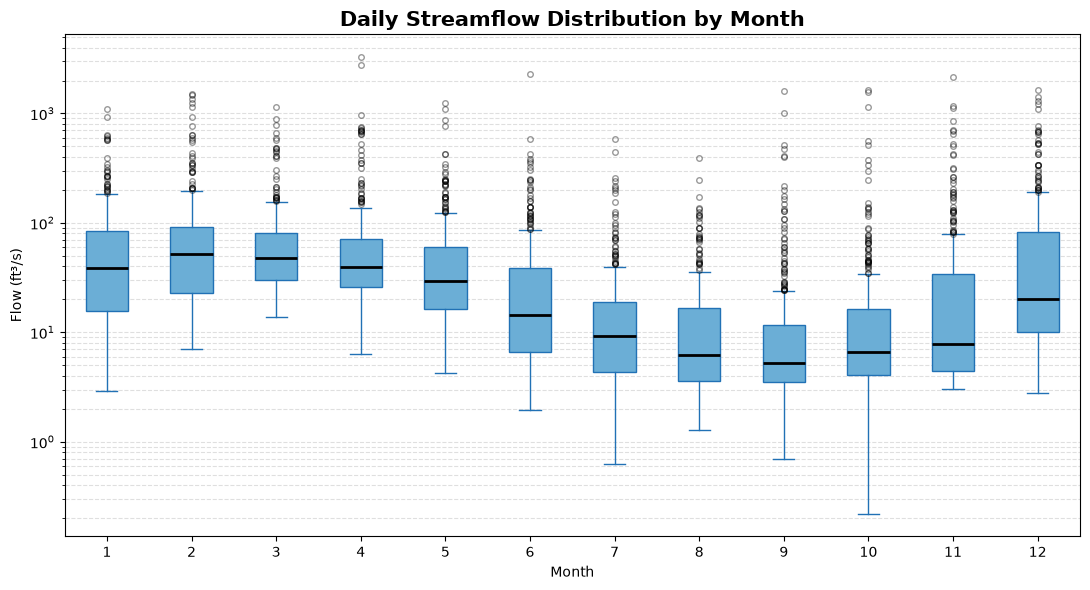

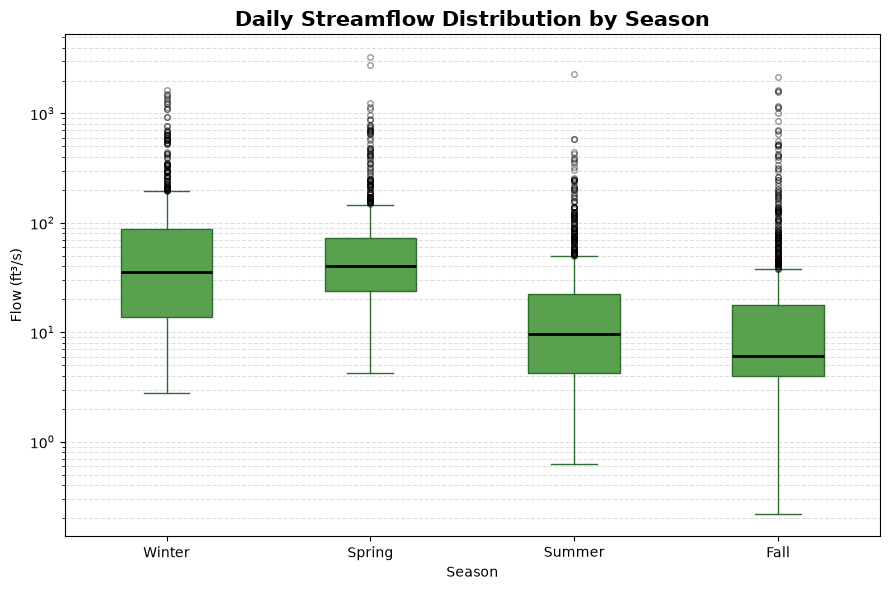

<Figure size 640x480 with 0 Axes>

In [19]:
# Monthly flow distributions as a boxplot
months = range(1, 13)
monthly_data = [
    flow_df.loc[flow_df["month"] == month, "value"]
    for month in months
]
# Monthly flow distributions
fig, ax = plt.subplots(figsize=(11, 6))

ax.boxplot(
    monthly_data,
    tick_labels=list(months),
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
    boxprops={"facecolor": "#6baed6", "edgecolor": "#2171b5"},
    whiskerprops={"color": "#2171b5"},
    capprops={"color": "#2171b5"},
    flierprops={"marker": "o", "markersize": 4, "alpha": 0.4},
)

ax.set_yscale("log")
ax.set_title("Daily Streamflow Distribution by Month", fontsize=15, weight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Flow (ft³/s)")
ax.grid(axis="y", linestyle="--", alpha=0.4, which="both")
plt.tight_layout()
plt.show()

season_order=['Winter', 'Spring', 'Summer', 'Fall']

# Seasonal flow distributions
seasonal_data = [
    flow_df.loc[flow_df["season"] == season, "value"]
    for season in season_order
]

fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    seasonal_data,
    tick_labels=season_order,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
    boxprops={"facecolor": "#59a14f", "edgecolor": "#2f6b2f"},
    whiskerprops={"color": "#2f6b2f"},
    capprops={"color": "#2f6b2f"},
    flierprops={"marker": "o", "markersize": 4, "alpha": 0.4},
)

ax.set_yscale("log")
ax.set_title("Daily Streamflow Distribution by Season", fontsize=15, weight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Flow (ft³/s)")
ax.grid(axis="y", linestyle="--", alpha=0.4, which="both")
plt.tight_layout()
plt.show()

ax.set_title("Daily Streamflow Distribution by Month", fontsize=15, weight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Flow (ft³/s)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



## Flow Forcasting using decision trees

1. Create extra features
    - lagged features
    - rolling means
    - day of year and month

2. Test/train split
    - for timeseries, you should split by chunk of time, not randomly

3. XGboost
    - gradient boosted decision trees

In [20]:
np.random.seed(42)
df = flow_df.set_index('time')
df = df[['value']]


def create_features(data, target_col="value"):
    df_feat = data.copy()
    
    # Target: Flow 1-day into the future
    df_feat["target_flow"] = df_feat[target_col].shift(-1)
    
    # 1. Lags (past observations)
    for lag in [1, 2, 3, 7, 14, 30, 365]:
        df_feat[f"lag_{lag}"] = df_feat[target_col].shift(lag)
    
    # 2. Rolling statistics (short and seasonal memory)
    lagged = df_feat[target_col].shift(1)
    df_feat["flow_diff_1"] = df_feat[target_col].diff(1)
    df_feat["rolling_sum_3"] = lagged.rolling(window=3).sum()
    df_feat["rolling_mean_7"] = lagged.rolling(window=7).mean()
    df_feat["rolling_std_7"] = lagged.rolling(window=7).std()
    df_feat["rolling_mean_30"] = lagged.rolling(window=30).mean()
    df_feat["rolling_mean_90"] = lagged.rolling(window=90).mean()
    df_feat["rolling_min_30"] = lagged.rolling(window=30).min()
    df_feat["rolling_max_30"] = lagged.rolling(window=30).max()
    
    # 3. Calendar features and seasonal cycles
    df_feat["day_of_year"] = df_feat.index.dayofyear
    df_feat["day_of_week"] = df_feat.index.dayofweek
    df_feat["month"] = df_feat.index.month
    df_feat["day_of_year_sin"] = np.sin(2 * np.pi * df_feat["day_of_year"] / 365.25)
    df_feat["day_of_year_cos"] = np.cos(2 * np.pi * df_feat["day_of_year"] / 365.25)
    
    # Drop rows with NaN values created by shifts/rolling windows
    df_feat = df_feat.dropna()
    return df_feat


df_model = create_features(df, target_col="value")
df_model.head(3)

,value,target_flow,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,lag_365,flow_diff_1,...,rolling_std_7,rolling_mean_30,rolling_mean_90,rolling_min_30,rolling_max_30,day_of_year,day_of_week,month,day_of_year_sin,day_of_year_cos
time,,,,,,,,,,,,,,,,,,,,,
2020-01-01,16.2,20.7,13.9,268.0,635.0,47.4,125.0,60.4,125.0,2.3,...,218.185852,125.663333,142.951111,13.9,1110.0,1,2,1,0.017202,0.999852
2019-12-31,20.7,19.6,16.2,13.9,268.0,54.2,160.0,56.4,109.0,4.5,...,221.688077,124.190000,142.685556,13.9,1110.0,365,1,12,-0.004301,0.999991
2019-12-30,19.6,13.7,20.7,16.2,13.9,80.6,53.5,64.6,119.0,-1.1,...,225.133312,123.000000,142.406667,13.9,1110.0,364,0,12,-0.021501,0.999769


In [21]:
# Train/Test cutoff date
split_date = "2019-01-01"

train = df_model[df_model.index < split_date]
test = df_model[df_model.index >= split_date]

# Avoid including the target or an accidental duplicate column in the feature list
feature_cols = [c for c in df_model.columns if c not in ["target_flow", "value"]]
X_train, y_train = train[feature_cols], train["target_flow"]
X_test, y_test = test[feature_cols], test["target_flow"]

print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

Train samples: 3286 | Test samples: 366


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

# Define Nash-Sutcliffe Efficiency function
def nash_sutcliffe_efficiency(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))

# Log-transform target for comparison only
# These models can work on raw flow, but log-transform can help when the target is highly skewed.
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# XGBoost model on log-transformed target
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=2,
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train_log)

xgb_pred_log = xgb_model.predict(X_test)
xgb_pred = np.expm1(xgb_pred_log)

# Random Forest baseline on raw target (more robust to skewed targets, but less extrapolative)
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Evaluate on original scale
xgb_rmse = root_mean_squared_error(y_test, xgb_pred)
rf_rmse = root_mean_squared_error(y_test, rf_pred)

print(f"--- Evaluation on Test Period ---")
print(f"XGBoost RMSE: {xgb_rmse:.2f} cfs ")
print(f"Random Forest RMSE: {rf_rmse:.2f} cfs ")

--- Evaluation on Test Period ---
XGBoost RMSE: 189.53 cfs 
Random Forest RMSE: 167.46 cfs 


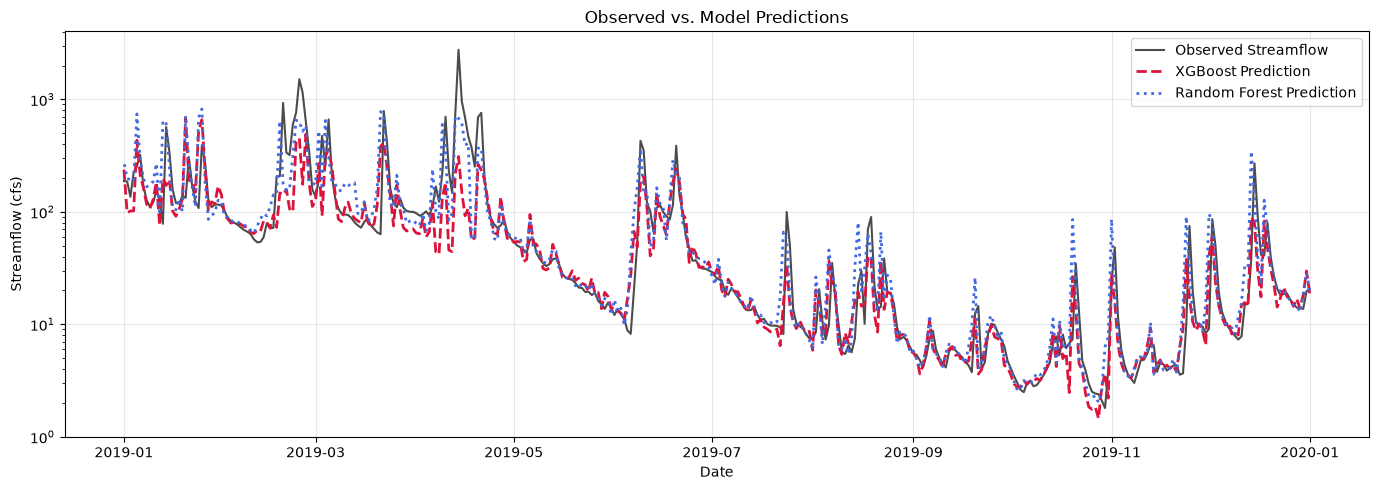

In [23]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label="Observed Streamflow", color="black", alpha=0.7)
plt.plot(y_test.index, xgb_pred, label="XGBoost Prediction", color="crimson", linestyle="--", linewidth=2)
plt.plot(y_test.index, rf_pred, label="Random Forest Prediction", color="royalblue", linestyle=":", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Streamflow (cfs)")
plt.title("Observed vs. Model Predictions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.yscale('log')
plt.show()

## Pandas vs. Polars performance

This benchmark runs the same cleaning, date-feature, rolling-window, and grouped-summary operations in both libraries. The source file has only about 4,000 rows, so the benchmark repeats it in memory to make timing differences visible.

***I Use claude code to help with this analysis since I dont polars syntax**

In [24]:
import timeit

# Both libraries receive the same rows and perform the same operations.
pandas_source = pd.read_csv(file)
polars_source = pl.read_csv(file, try_parse_dates=False)
scale = 100
pandas_bench = pd.concat([pandas_source] * scale, ignore_index=True)
polars_bench = pl.concat([polars_source] * scale)

def pandas_analysis(df):
    result = df.loc[df["approval_status"].eq("Approved"), ["time", "value"]].copy()
    result["time"] = pd.to_datetime(result["time"])
    result["value"] = pd.to_numeric(result["value"])
    result = result.sort_values("time")
    result["month"] = result["time"].dt.month
    result["year"] = result["time"].dt.year
    result["season"] = result["month"].map({12: "Winter", 1: "Winter", 2: "Winter",
        3: "Spring", 4: "Spring", 5: "Spring",
        6: "Summer", 7: "Summer", 8: "Summer",
        9: "Fall", 10: "Fall", 11: "Fall"})
    result["rolling_mean_7"] = result["value"].shift(1).rolling(7, min_periods=1).mean()
    summary = (result.groupby(["year", "month", "season"], observed=True)["value"]
        .agg(["mean", "max", "min"]).reset_index())
    return result, summary

def polars_analysis(df):
    result = (
        df.filter(pl.col("approval_status") == "Approved")
        .select(["time", "value"])
        .with_columns([
            pl.col("time").str.strptime(pl.Date, "%Y-%m-%d", strict=False),
            pl.col("value").cast(pl.Float64),
        ])
        .sort("time")
        .with_columns([
            pl.col("time").dt.month().alias("month"),
            pl.col("time").dt.year().alias("year"),
            pl.col("value").shift(1).rolling_mean(window_size=7, min_samples=1).alias("rolling_mean_7"),
        ])
        .with_columns(
            pl.when(pl.col("month").is_in([12, 1, 2])).then(pl.lit("Winter"))
            .when(pl.col("month").is_in([3, 4, 5])).then(pl.lit("Spring"))
            .when(pl.col("month").is_in([6, 7, 8])).then(pl.lit("Summer"))
            .otherwise(pl.lit("Fall")).alias("season")
        )
    )
    summary = (result.group_by(["year", "month", "season"])
        .agg([pl.col("value").mean().alias("mean"),
              pl.col("value").max().alias("max"),
              pl.col("value").min().alias("min")])
        .sort(["year", "month", "season"]))
    return result, summary

# Validate equivalent results before timing.
_, pandas_summary = pandas_analysis(pandas_source)
_, polars_summary = polars_analysis(polars_source)
pandas_summary = pandas_summary.sort_values(["year", "month", "season"]).reset_index(drop=True)
polars_rows = polars_summary.to_dicts()
pandas_rows = pandas_summary.to_dict(orient="records")
assert [(r["year"], r["month"], r["season"]) for r in pandas_rows] == [(r["year"], r["month"], r["season"]) for r in polars_rows]
assert np.allclose(
    [[r["mean"], r["max"], r["min"]] for r in pandas_rows],
    [[r["mean"], r["max"], r["min"]] for r in polars_rows],
    equal_nan=True,
)

def median_seconds(fn, arg, repeats=5):
    times = timeit.repeat(lambda: fn(arg), repeat=repeats, number=1)
    return np.median(times)

pandas_seconds = median_seconds(pandas_analysis, pandas_bench)
polars_seconds = median_seconds(polars_analysis, polars_bench)
benchmark = pd.DataFrame({
    "library": ["pandas", "polars"],
    "median_seconds": [pandas_seconds, polars_seconds],
    "memory_mb": [
        pandas_bench.memory_usage(deep=True).sum() / 1024**2,
        polars_bench.estimated_size() / 1024**2,
    ],
})
benchmark["speedup_vs_pandas"] = pandas_seconds / benchmark["median_seconds"]
benchmark


,library,median_seconds,memory_mb,speedup_vs_pandas
0,pandas,0.150904,75.569279,1.000000
1,polars,0.246623,54.062748,0.611881
